In [1]:
import sys
import torch 

""" Run this cell before you run anything. This ensures the modular imports work correctly"""

working_root_directory="/teamspace/studios/this_studio/resnet18_cifar10_classifier"

if working_root_directory not in sys.path: 
    sys.path.append(working_root_directory)

In [2]:
from utils.helper_utils import (
    load_prepare_cifar10,
    build_transforms,
    load_resnet18
    )
from utils.visualization_utils import (
    load_and_plot_metrics_history,
    load_csv_main_model_metrics_history,
    extract_dataframe,
    confusion_matrix_plot,
    sample_image,
    each_class_accuracy
    )
from config.exp_config import dataset_dir,baseline_model_dir,csv_file_path
import matplotlib.pyplot as plt 

In [3]:
#Device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [4]:
def get_datasets(baseline_model:bool):
        
        flag=True 
        if baseline_model:
                flag=False

        #download cifar10 dataset if it doesn't exist or it is corrupted
        train_dataset,val_dataset,test_dataset=load_prepare_cifar10(
                dataset_path=f"../{dataset_dir}", #notice i have chaged the dataset dir due to current script running jupyter notebook dir
                build_transforms=build_transforms,
                image_size=224,
                standard_aug=flag #set False not to be applied standard augmentation or True
                
                )
        return train_dataset,val_dataset,test_dataset 

In [5]:
train_dataset,val_dataset,test_dataset=get_datasets(baseline_model=True)

downloaded cifar10 dataset ...


In [6]:
print(f"length of train dataset after splitting {len(train_dataset)}")
print(f"length of val dataset after splitting {len(val_dataset)}")
print(f"length of test dataset  {len(test_dataset)}")

#get the classes
cifar10_classes=train_dataset.subset.dataset.classes
cifar10_classes_len=len(cifar10_classes)
#num classes
print(cifar10_classes)
print(f"Len of classes {cifar10_classes_len}")

length of train dataset after splitting 40000
length of val dataset after splitting 10000
length of test dataset  10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Len of classes 10


In [7]:
#call pretrained resnet18 and freezed backbone model
model=load_resnet18(device=device)
for name,param in model.named_parameters():
  print(f"{name}:{param.requires_grad}")

print(f"classification layer head {model.fc.out_features}")

conv1.weight:False
bn1.weight:False
bn1.bias:False
layer1.0.conv1.weight:False
layer1.0.bn1.weight:False
layer1.0.bn1.bias:False
layer1.0.conv2.weight:False
layer1.0.bn2.weight:False
layer1.0.bn2.bias:False
layer1.1.conv1.weight:False
layer1.1.bn1.weight:False
layer1.1.bn1.bias:False
layer1.1.conv2.weight:False
layer1.1.bn2.weight:False
layer1.1.bn2.bias:False
layer2.0.conv1.weight:False
layer2.0.bn1.weight:False
layer2.0.bn1.bias:False
layer2.0.conv2.weight:False
layer2.0.bn2.weight:False
layer2.0.bn2.bias:False
layer2.0.downsample.0.weight:False
layer2.0.downsample.1.weight:False
layer2.0.downsample.1.bias:False
layer2.1.conv1.weight:False
layer2.1.bn1.weight:False
layer2.1.bn1.bias:False
layer2.1.conv2.weight:False
layer2.1.bn2.weight:False
layer2.1.bn2.bias:False
layer3.0.conv1.weight:False
layer3.0.bn1.weight:False
layer3.0.bn1.bias:False
layer3.0.conv2.weight:False
layer3.0.bn2.weight:False
layer3.0.bn2.bias:False
layer3.0.downsample.0.weight:False
layer3.0.downsample.1.weight:Fa

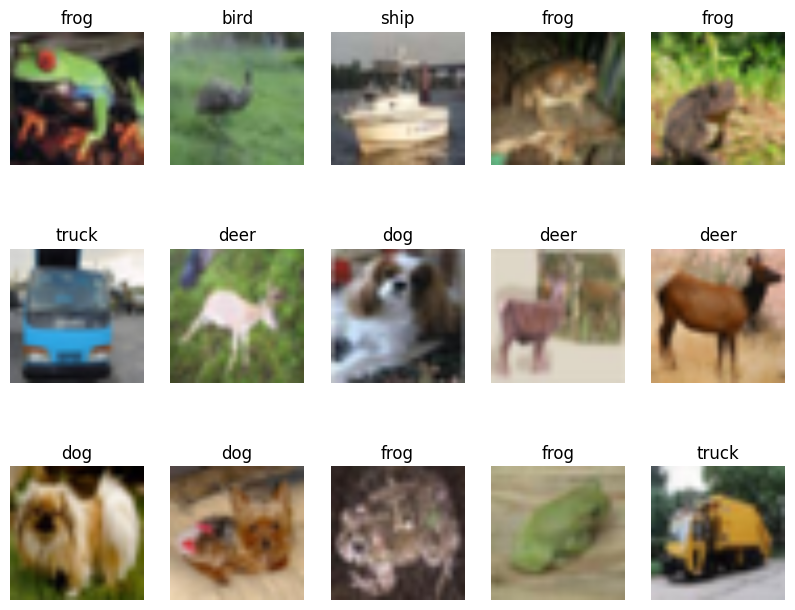

In [8]:
sample_image(train_dataset,test_set=False) #plot unnormalized 15 images

# Baseline Model

## Baseline model plot for train accuracy/loss and val accuracy/loss to optimize the model performance

##### Note: when using "load_and_plot_metrics_history" for plotting the baseline metrics or main model metrics histories, note that baseline=True and baseline_path are only used for plotting baseline history. When setting baseline=True, don't forget to set the baseline_path too.

baseline - True is only for baseline plots


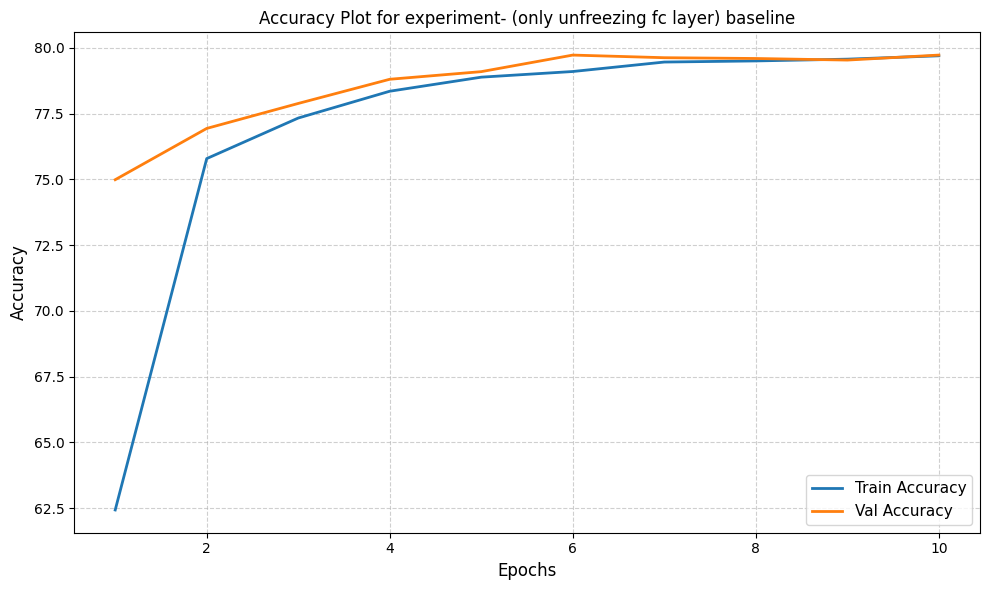

Accuracy plot has been plotted


Train Accuracy for (only unfreezing fc layer) baseline: 79.70
Val Accuracy for (only unfreezing fc layer) baseline: 79.73


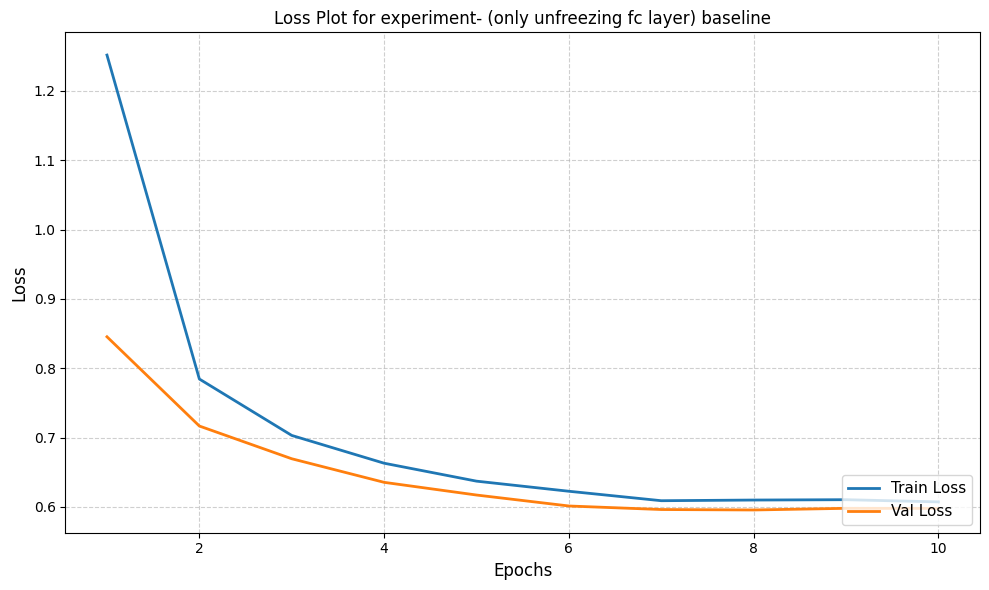

Loss plot has been plotted


Train Loss for (only unfreezing fc layer) baseline: 0.61
Val Loss for (only unfreezing fc layer) baseline: 0.60


In [9]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=10,
    experiment_name="(only unfreezing fc layer) baseline",
    baseline=True,
    baseline_path=baseline_model_dir
)

# Experiment 2
## CSV file for experiment 2 (baseline + unfreezing layer4 and fc)

In [9]:
exp2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp2")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v2.csv']


In [10]:
#extract and preprare the csv experiment2 dataframe to dictionary for easier plotting 
experiment2_prepared_csv=extract_dataframe(df=exp2_csv)

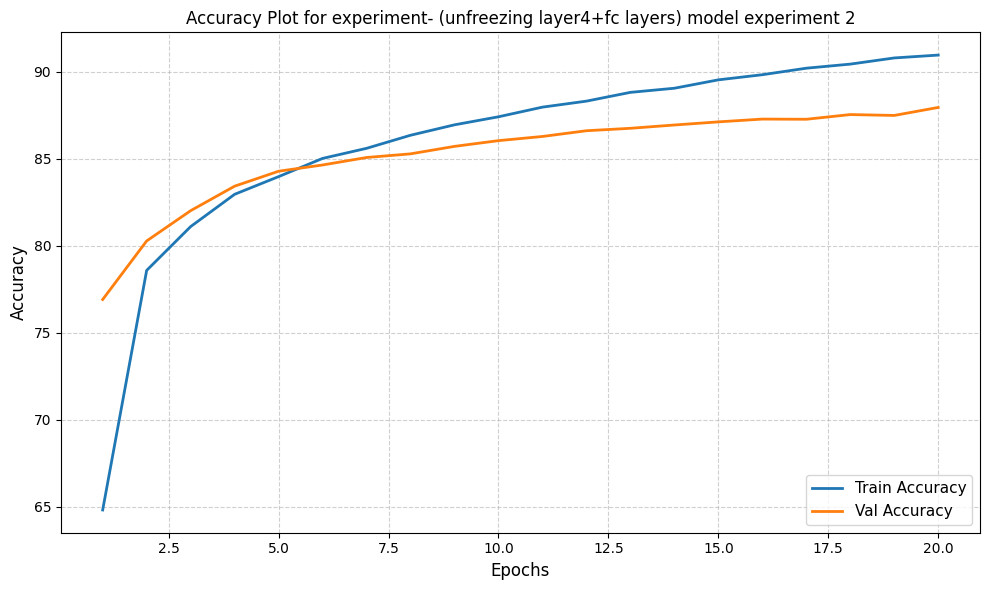

Accuracy plot has been plotted


Train Accuracy for (unfreezing layer4+fc layers) model experiment 2: 90.97
Val Accuracy for (unfreezing layer4+fc layers) model experiment 2: 87.96


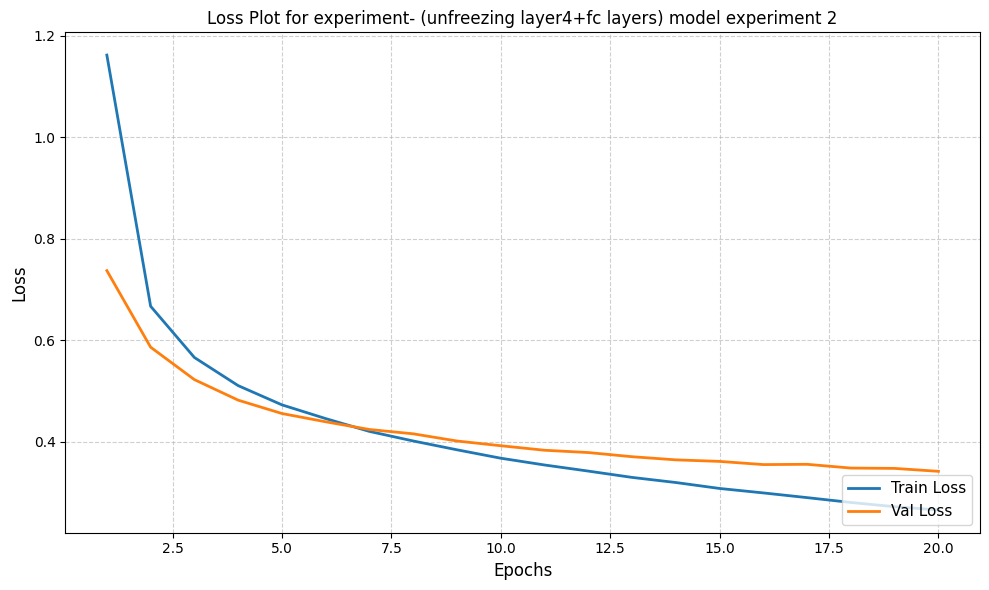

Loss plot has been plotted


Train Loss for (unfreezing layer4+fc layers) model experiment 2: 0.27
Val Loss for (unfreezing layer4+fc layers) model experiment 2: 0.34


In [11]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment2_prepared_csv["epoch"],
    experiment_name="(unfreezing layer4+fc layers) model experiment 2",
    baseline=False,
    main_model_history=experiment2_prepared_csv
)